# **Linear regression - Training Window**

Marek Šugár

In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# ML Stuff
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SelectKBest, f_regression


In [4]:
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

In [11]:
performance_trackerENPH = {}

for variable_count in range(50, 541, 10):
    for ticker in ["ENPH"]:
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
        
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 8
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue

            # Feature selection
            selector = SelectKBest(score_func=f_regression, k=variable_count)
            selector.fit(Training_Features, Training_Target)
            selected_features = Training_Features.columns[selector.get_support()]

            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features[selected_features])
            Test_Features = scaler.transform(Test_Features[selected_features])

            # Fit KNN
            MODEL = LinearRegression()
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
        
        # Save results
        performance_trackerENPH[variable_count] = np.mean(MAPEs)
        print(variable_count, np.mean(MAPEs))


50 4.347308716311602
60 4.263596833248665
70 4.205902911281366
80 4.164065255433388
90 4.125898150210264
100 4.07760437318191
110 4.054610864856714
120 4.050400815417874
130 4.035507734721727
140 4.019374384785537
150 4.023448108310729
160 4.0270841034703215
170 4.015656415055953
180 3.993423945256956
190 3.991706143625093
200 3.9721626492376494
210 3.968339217964759
220 3.9605021248975167
230 3.960563024929152
240 3.976275499321058
250 3.9733416931389876
260 3.96823861028708
270 3.9557425776995743
280 3.9473873539989905
290 3.945664349352685
300 3.9370303537875673
310 3.9283835097900064
320 3.9193332003194215
330 3.913554637546306
340 3.9104229986308607
350 3.9045624558816256
360 3.90096622547914
370 3.8983390122132047
380 3.889770069327987
390 3.885866611201366
400 3.8843580349965743
410 3.8726851336316415
420 3.873105375201846
430 3.8712172661612976
440 3.871245328649446
450 3.871127540077912
460 3.871127540077912
470 3.8711275400779117
480 3.8711275400779117
490 3.8711275400779117


Text(0, 0.5, 'MAPE')

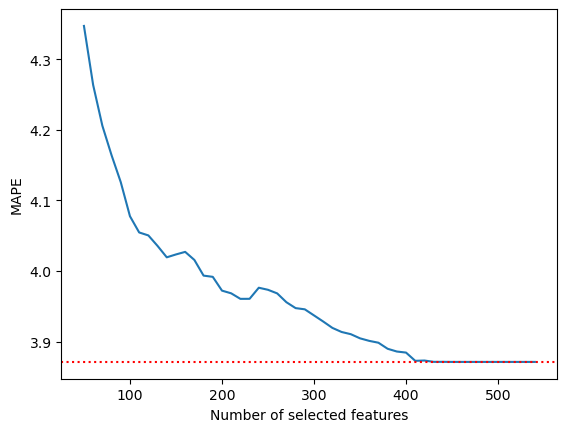

In [13]:
plt.plot(performance_trackerENPH.keys(), performance_trackerENPH.values())

plt.axhline(3.8711275400779117, linestyle="dotted", c="red")

plt.xlabel("Number of selected features")
plt.ylabel("MAPE")

In [15]:
performance_trackerROP = {}

for variable_count in range(50, 541, 10):
    for ticker in ["ROP"]:
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
        
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 8
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue

            # Feature selection
            selector = SelectKBest(score_func=f_regression, k=variable_count)
            selector.fit(Training_Features, Training_Target)
            selected_features = Training_Features.columns[selector.get_support()]

            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features[selected_features])
            Test_Features = scaler.transform(Test_Features[selected_features])

            # Fit KNN
            MODEL = LinearRegression()
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
        
        # Save results
        performance_trackerROP[variable_count] = np.mean(MAPEs)
        print(variable_count, np.mean(MAPEs))
#1.1550425098272497


50 1.3122849967838226
60 1.2971008730220253
70 1.2719942452948325
80 1.2659996240803788
90 1.2578443552649936
100 1.245266604464688
110 1.23880628755483
120 1.231020787904172
130 1.2227537077930142
140 1.2163510943043365
150 1.205003361285375
160 1.1990116155228667
170 1.1991392943111039
180 1.190608454172515
190 1.1871091789869126
200 1.1922547576100868
210 1.1873830987816587
220 1.1839831567342078
230 1.18333297883794
240 1.1796557690679368
250 1.1759958475440357
260 1.1731702487479865
270 1.1722836637289524
280 1.173797515757562
290 1.1684811703483056
300 1.1705951760215256
310 1.1714526250149528
320 1.1725503221018
330 1.171790261260604
340 1.1693992572090364
350 1.167507865843061
360 1.1665050313617393
370 1.1657370910349476
380 1.163155779054622
390 1.1616090484246597
400 1.1582778678931092
410 1.1573117739691918
420 1.1572584800558294
430 1.1559025998923613
440 1.155797859475153
450 1.1550425098272497
460 1.1550425098272497
470 1.1550425098272497
480 1.1550425098272499
490 1.155

Text(0, 0.5, 'MAPE')

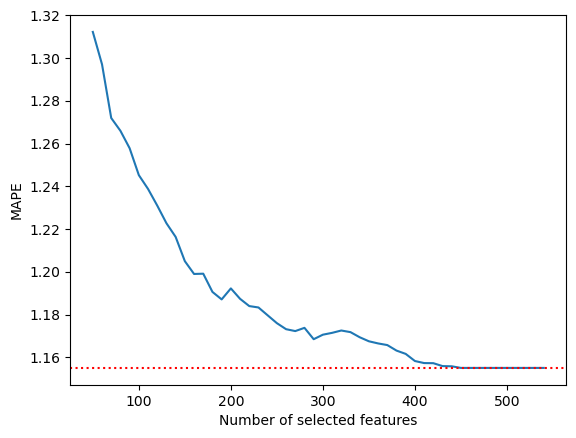

In [17]:
plt.plot(performance_trackerROP.keys(), performance_trackerROP.values())

plt.axhline(1.1550425098272497, linestyle="dotted", c="red")

plt.xlabel("Number of selected features")
plt.ylabel("MAPE")

In [19]:
performance_trackerSMCI = {}

for variable_count in range(50, 541, 10):
    for ticker in ["SMCI"]:
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
        
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 8
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue

            # Feature selection
            selector = SelectKBest(score_func=f_regression, k=variable_count)
            selector.fit(Training_Features, Training_Target)
            selected_features = Training_Features.columns[selector.get_support()]

            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features[selected_features])
            Test_Features = scaler.transform(Test_Features[selected_features])

            # Fit KNN
            MODEL = LinearRegression()
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
        
        # Save results
        performance_trackerSMCI[variable_count] = np.mean(MAPEs)
        print(variable_count, np.mean(MAPEs))
#3.24000756609227


50 3.7909707057375677
60 3.697215109558226
70 3.655227220800129
80 3.571068364646874
90 3.522710788828469
100 3.4891719988101153
110 3.467733770581908
120 3.452569480418406
130 3.4142942426631637
140 3.396563438367346
150 3.386277806508827
160 3.372054127643252
170 3.344542397832941
180 3.322391562544775
190 3.3068955050346314
200 3.3026601211192017
210 3.3062916019068878
220 3.3033175434437947
230 3.2897482904189
240 3.281493286831356
250 3.2827012188676927
260 3.2966988736834595
270 3.2785760212303257
280 3.2744809734518077
290 3.2723244637473896
300 3.2712911107533498
310 3.271535774907061
320 3.259721175216446
330 3.259308213891002
340 3.2566069932908137
350 3.2598018430247246
360 3.262689815315667
370 3.261275187641145
380 3.2561196101043457
390 3.2497567218915826
400 3.2431586300359525
410 3.241140851064835
420 3.241922321104222
430 3.2399485486637087
440 3.2404957388303384
450 3.24000756609227
460 3.24000756609227
470 3.24000756609227
480 3.24000756609227
490 3.24000756609227
50

Text(0, 0.5, 'MAPE')

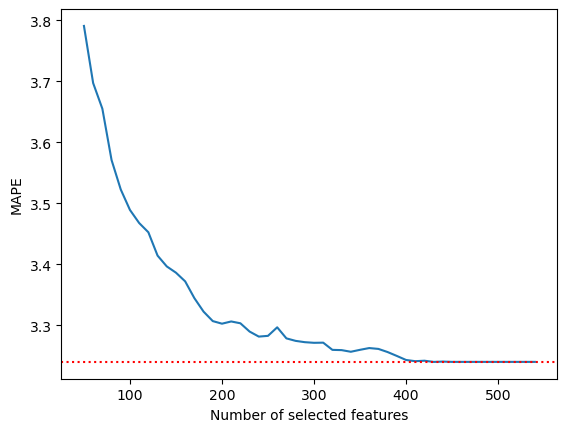

In [20]:
plt.plot(performance_trackerSMCI.keys(), performance_trackerSMCI.values())

plt.axhline(3.24000756609227, linestyle="dotted", c="red")

plt.xlabel("Number of selected features")
plt.ylabel("MAPE")

In [21]:
performance_trackerIBM = {}

for variable_count in range(50, 541, 10):
    for ticker in ["IBM"]:
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
        
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 8
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue

            # Feature selection
            selector = SelectKBest(score_func=f_regression, k=variable_count)
            selector.fit(Training_Features, Training_Target)
            selected_features = Training_Features.columns[selector.get_support()]

            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features[selected_features])
            Test_Features = scaler.transform(Test_Features[selected_features])

            # Fit KNN
            MODEL = LinearRegression()
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
        
        # Save results
        performance_trackerIBM[variable_count] = np.mean(MAPEs)
        print(variable_count, np.mean(MAPEs))
#1.226912361562705


50 1.4009048341861936
60 1.3712455354391742
70 1.3473815368380815
80 1.3358744501373243
90 1.3388928304080236
100 1.328144995700506
110 1.3173061974166527
120 1.3091396974317147
130 1.2966080598498815
140 1.2927229497878099
150 1.278111670873433
160 1.2731395327011827
170 1.2669052331188728
180 1.256527954043579
190 1.2513741154446882
200 1.2468145268812565
210 1.2523788652781354
220 1.253062149168433
230 1.2509398368848275
240 1.2460159692620243
250 1.2473446780246
260 1.2449116320353817
270 1.240619008557548
280 1.2388925587189064
290 1.2377373457245222
300 1.2331122056380317
310 1.2304360981387688
320 1.2295481883172625
330 1.2284125556670764
340 1.2271791500313831
350 1.2275923749678734
360 1.225670200103619
370 1.2286438211930633
380 1.2315412911514887
390 1.2297918987053487
400 1.2264231488254398
410 1.2283992868850715
420 1.2295643308586885
430 1.228460866207169
440 1.2275890982546973
450 1.226912361562705
460 1.226912361562705
470 1.226912361562705
480 1.226912361562705
490 1.2

Text(0, 0.5, 'MAPE')

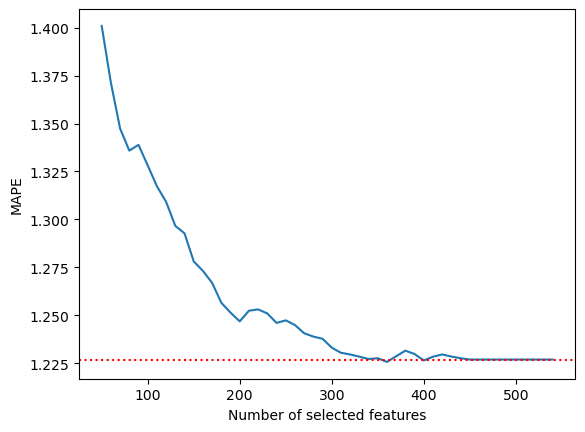

In [22]:
plt.plot(performance_trackerIBM.keys(), performance_trackerIBM.values())

plt.axhline(1.226912361562705, linestyle="dotted", c="red")

plt.xlabel("Number of selected features")
plt.ylabel("MAPE")